# Pré-processamento

Carregamento das bases de treino, validação e teste geradas na etapa anterior.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

In [2]:
DADOS_INTERIM = Path.cwd().parent / 'data' / 'interim'

X_train = pd.read_parquet(DADOS_INTERIM / 'X_train.parquet')
y_train = pd.read_parquet(DADOS_INTERIM / 'y_train.parquet').squeeze('columns')

X_val = pd.read_parquet(DADOS_INTERIM / 'X_val.parquet')
y_val = pd.read_parquet(DADOS_INTERIM / 'y_val.parquet').squeeze('columns')

X_test = pd.read_parquet(DADOS_INTERIM / 'X_test.parquet')
y_test = pd.read_parquet(DADOS_INTERIM / 'y_test.parquet').squeeze('columns')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape} | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape} | y_test:  {y_test.shape}')

X_train: (196806, 146) | y_train: (196806,)
X_val:   (49202, 146) | y_val:   (49202,)
X_test:  (61503, 146) | y_test:  (61503,)


In [3]:
X_train

,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,SAQUE_LIMITE_RATIO,SALDO_RENDA_RATIO,PCT_PAGAMENTO_REALIZADO,VALOR_MEDIO_PARCELA,ATRASO_POR_PARCELA,HISTORICO_FINANCEIRO_TOTAL,CONTATOS_POR_CREDITO,DOCUMENTOS_POR_CREDITO,CONSULTAS_HISTORICO_RATIO,TEMPO_CREDITO_POR_IDADE
0,Cash loans,N,Y,112500.0,808650.0,23773.5,675000.0,Unaccompanied,Working,Secondary / secondary special,...,NaN,NaN,0.927172,11785.869141,-1.265625,NaN,NaN,NaN,NaN,NaN
1,Cash loans,N,Y,270000.0,733315.5,39199.5,679500.0,Unaccompanied,Commercial associate,Higher education,...,0.00000,0.000000,0.923237,18497.349783,-0.456522,21.0,0.230769,0.076923,0.0,-0.037479
2,Cash loans,N,Y,112500.0,555273.0,18040.5,463500.0,"Spouse, partner",Working,Secondary / secondary special,...,NaN,NaN,1.000000,6094.386000,-195.200000,12.0,0.090909,0.090909,NaN,-0.081419
3,Cash loans,Y,Y,292500.0,835380.0,40320.0,675000.0,Unaccompanied,Working,Secondary / secondary special,...,NaN,NaN,1.000000,51512.237027,-0.594595,31.0,0.125000,0.125000,NaN,-0.041474
4,Cash loans,N,Y,202500.0,1724220.0,50544.0,1350000.0,"Spouse, partner",Working,Secondary / secondary special,...,NaN,NaN,1.000000,91922.700000,-51.600000,7.0,0.200000,0.200000,NaN,-0.051175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196801,Revolving loans,N,Y,225000.0,270000.0,13500.0,270000.0,Unaccompanied,Working,Secondary / secondary special,...,NaN,NaN,0.974873,6156.901250,-1.666667,5.0,0.666667,0.333333,NaN,-0.014474
196802,Cash loans,Y,N,180000.0,225000.0,11488.5,225000.0,Unaccompanied,Working,Secondary / secondary special,...,NaN,NaN,0.861200,9844.531579,-14.263158,7.0,0.333333,0.333333,NaN,-0.050003
196803,Cash loans,Y,Y,180000.0,521280.0,23089.5,450000.0,Unaccompanied,Working,Higher education,...,NaN,NaN,0.861370,7214.151000,-176.733333,NaN,NaN,NaN,NaN,NaN
196804,Revolving loans,Y,Y,135000.0,247500.0,12375.0,247500.0,Unaccompanied,Working,Higher education,...,NaN,NaN,1.000000,22850.340000,-225.333333,4.0,0.333333,0.000000,NaN,-0.026861


In [4]:
import numpy as np

CATEGORICAS_FORCADAS = []
NUMERICAS_FORCADAS = []

def separar_variaveis(df, categoricas_forcadas=None, numericas_forcadas=None):
    """Retorna listas mutuamente exclusivas de colunas categóricas e numéricas."""
    categoricas_forcadas = set(categoricas_forcadas or [])
    numericas_forcadas = set(numericas_forcadas or [])

    colunas_invalidas = (categoricas_forcadas | numericas_forcadas) - set(df.columns)
    if colunas_invalidas:
        raise KeyError(f'Colunas não encontradas: {sorted(colunas_invalidas)}')
    if categoricas_forcadas & numericas_forcadas:
        raise ValueError('Uma coluna não pode ser forçada como categórica e numérica ao mesmo tempo.')

    categoricas = set(
        df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns
    )
    numericas = set(df.select_dtypes(include=[np.number]).columns)

    categoricas = (categoricas - numericas_forcadas) | categoricas_forcadas
    numericas = (numericas - categoricas_forcadas) | numericas_forcadas

    nao_classificadas = set(df.columns) - categoricas - numericas
    if nao_classificadas:
        raise TypeError(
            'Há colunas com dtype não classificado. Defina-as em uma das listas de exceção: '
            f'{sorted(nao_classificadas)}'
        )

    categoricas = sorted(categoricas)
    numericas = sorted(numericas)

    assert not (set(categoricas) & set(numericas))
    assert set(categoricas) | set(numericas) == set(df.columns)
    return categoricas, numericas

variaveis_categoricas, variaveis_numericas = separar_variaveis(
    X_train,
    categoricas_forcadas=CATEGORICAS_FORCADAS,
    numericas_forcadas=NUMERICAS_FORCADAS,
)

print(f'Variáveis categóricas: {len(variaveis_categoricas)}')
print(f'Variáveis numéricas: {len(variaveis_numericas)}')
print('Total de colunas classificadas:', len(variaveis_categoricas) + len(variaveis_numericas))

Variáveis categóricas: 15
Variáveis numéricas: 131
Total de colunas classificadas: 146


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder


def criar_preprocessador(
    variaveis_numericas,
    variaveis_categoricas,
):
    """Cria o pipeline de pré-processamento."""

    pipeline_numerico = Pipeline(
        steps=[
            ("scaler", StandardScaler())
        ]
    )

    pipeline_categorico = Pipeline(
        steps=[
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    preprocessador = (
        ColumnTransformer(
            transformers=[
                (
                    "numericas",
                    pipeline_numerico,
                    variaveis_numericas,
                ),
                (
                    "categoricas",
                    pipeline_categorico,
                    variaveis_categoricas,
                ),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )
        .set_output(transform="pandas")
    )

    return preprocessador

In [6]:
preprocessador = criar_preprocessador(
    variaveis_numericas=variaveis_numericas,
    variaveis_categoricas=variaveis_categoricas,
)

X_train_processado = preprocessador.fit_transform(X_train)
X_val_processado = preprocessador.transform(X_val)
X_test_processado = preprocessador.transform(X_test)

### Seleção de variáveis

A técnica que será usado para reduzir mais as variáveis se chama, RFECV (Recursive Feature Elimination With Cross-Validation) é um método de seleção automática de variáveis que combina:

- RFE (Recursive Feature Elimination): remove iterativamente as variáveis menos importantes.
- Validação cruzada: Avalia o desempenho do modelo em cada etapa para encontrar automaticamente o melhor número de variáveis.

In [7]:
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
import pandas as pd
import numpy as np
import copy


def calcular_importancia_e_score_cv(
    modelo,
    X,
    y,
    variaveis,
    n_splits=3,
    n_repeats=5,
    random_state=42,
):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    importancias = []
    scores = []


    for train_idx, val_idx in skf.split(X, y):

        X_tr = X.iloc[train_idx][variaveis]
        X_fold_val = X.iloc[val_idx][variaveis]

        y_tr = y.iloc[train_idx]
        y_fold_val = y.iloc[val_idx]


        modelo_cv = clone(modelo)

        modelo_cv.fit(
            X_tr,
            y_tr
        )


        y_prob = modelo_cv.predict_proba(
            X_fold_val
        )[:,1]


        pr_auc = average_precision_score(
            y_fold_val,
            y_prob
        )

        scores.append(pr_auc)


        resultado = permutation_importance(
            estimator=modelo_cv,
            X=X_fold_val,
            y=y_fold_val,
            scoring="average_precision",
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1,
        )


        importancias.append(
            resultado.importances_mean
        )


    return (
        pd.Series(
            np.mean(importancias, axis=0),
            index=variaveis
        ).sort_values(),

        np.mean(scores),

        np.std(scores)
    )


def selecionar_variaveis(
    modelo,
    X_train,
    y_train,
    step=0.05,
    min_features=20,
    n_splits=3,
    n_repeats=5,
    random_state=42,
):

    variaveis = list(X_train.columns)

    historico = []


    while len(variaveis) >= min_features:


        importancias, pr_auc, std_auc = (
            calcular_importancia_e_score_cv(
                modelo=modelo,
                X=X_train,
                y=y_train,
                variaveis=variaveis,
                n_splits=n_splits,
                n_repeats=n_repeats,
                random_state=random_state,
            )
        )


        print(
            f"{len(variaveis):3d} variáveis | "
            f"PR AUC={pr_auc:.5f} ± {std_auc:.5f}"
        )


        historico.append({
            "n_variaveis": len(variaveis),
            "pr_auc": pr_auc,
            "std_pr_auc": std_auc,
            "variaveis": variaveis.copy()
        })


        quantidade_remover = max(
            1,
            int(len(variaveis) * step)
        )


        variaveis = importancias.index[
            quantidade_remover:
        ].tolist()


    return (
        variaveis,
        pd.DataFrame(historico)
    )

In [8]:
modelo = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.05,
    num_leaves=20,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

In [9]:
melhores_variaveis, historico = selecionar_variaveis(
    modelo=modelo,
    X_train=X_train_processado,
    y_train=y_train,
    step=0.05,
    min_features=20,
    n_splits=3,
    n_repeats=5,
)

146 variáveis | PR AUC=0.26234 ± 0.00487
139 variáveis | PR AUC=0.26280 ± 0.00310
133 variáveis | PR AUC=0.26324 ± 0.00201
127 variáveis | PR AUC=0.26195 ± 0.00389
121 variáveis | PR AUC=0.26331 ± 0.00277
115 variáveis | PR AUC=0.26275 ± 0.00218
110 variáveis | PR AUC=0.26405 ± 0.00404
105 variáveis | PR AUC=0.26434 ± 0.00301
100 variáveis | PR AUC=0.26378 ± 0.00260
 95 variáveis | PR AUC=0.26373 ± 0.00085
 91 variáveis | PR AUC=0.26425 ± 0.00280
 87 variáveis | PR AUC=0.26338 ± 0.00200
 83 variáveis | PR AUC=0.26366 ± 0.00258
 79 variáveis | PR AUC=0.26410 ± 0.00261
 76 variáveis | PR AUC=0.26357 ± 0.00321
 73 variáveis | PR AUC=0.26415 ± 0.00250
 70 variáveis | PR AUC=0.26369 ± 0.00351
 67 variáveis | PR AUC=0.26414 ± 0.00198
 64 variáveis | PR AUC=0.26352 ± 0.00364
 61 variáveis | PR AUC=0.26354 ± 0.00197
 58 variáveis | PR AUC=0.26277 ± 0.00257
 56 variáveis | PR AUC=0.26130 ± 0.00195
 54 variáveis | PR AUC=0.26269 ± 0.00121
 52 variáveis | PR AUC=0.26203 ± 0.00149
 50 variáveis | 

In [10]:
melhores_variaveis = historico.loc[
    historico["n_variaveis"] == 67,
    "variaveis"
].iloc[0]

print(len(melhores_variaveis))
print(melhores_variaveis)

67
['BENS_RENDA_RATIO', 'LIMITE_TOTAL', 'TOTAL_PARCELAS', 'REG_CITY_NOT_LIVE_CITY', 'CONTATOS_POR_CREDITO', 'CNT_FAM_MEMBERS', 'AMT_REQ_CREDIT_BUREAU_QRT', 'FLAG_DOCUMENT_3', 'AREA_CONSTRUIDA_TOTAL', 'REGION_POPULATION_RELATIVE', 'QUALIDADE_MORADIA', 'HISTORICO_FINANCEIRO_TOTAL', 'EXT_SOURCE_2', 'ATRASO_POR_PARCELA', 'ORGANIZATION_TYPE', 'TEMPO_CADASTRO_ANOS', 'DEF_30_CNT_SOCIAL_CIRCLE', 'HISTORICO_MESES', 'CREDITOS_POR_IDADE', 'UTILIZACAO_LIMITE_BUREAU', 'EXT_SOURCE_MAX', 'PCT_CREDITOS_ATIVOS', 'NAME_INCOME_TYPE', 'DOCUMENTOS_POR_CREDITO', 'NAME_FAMILY_STATUS', 'FLAG_WORK_PHONE', 'TEMPO_DOCUMENTO_ANOS', 'PAGAMENTO_SALDO_RATIO', 'CREDITO_NEGADO_TOTAL', 'VALOR_CREDITO_TOTAL', 'DIAS_CREDITO_MEDIO', 'ATRASO_PAGAMENTO_MAX', 'TOTAL_FLAGS_DOCUMENTOS', 'TEMPO_CREDITO_POR_IDADE', 'REGION_RATING_CLIENT_W_CITY', 'DIVIDA_TOTAL', 'CREDITO_APROVADO_RENDA', 'SOLICITACOES_POR_EMPREGO', 'CREDITO_ATIVO', 'AMT_CREDIT', 'TEMPO_EMPREGADO_ANOS', 'VALOR_CREDITO_MEDIO_BUREAU', 'OCCUPATION_TYPE', 'SAQUE_LIMIT

In [11]:
melhores_variaveis = [
    "BENS_RENDA_RATIO",
    "LIMITE_TOTAL",
    "TOTAL_PARCELAS",
    "REG_CITY_NOT_LIVE_CITY",
    "CONTATOS_POR_CREDITO",
    "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "FLAG_DOCUMENT_3",
    "AREA_CONSTRUIDA_TOTAL",
    "REGION_POPULATION_RELATIVE",
    "QUALIDADE_MORADIA",
    "HISTORICO_FINANCEIRO_TOTAL",
    "EXT_SOURCE_2",
    "ATRASO_POR_PARCELA",
    "ORGANIZATION_TYPE",
    "TEMPO_CADASTRO_ANOS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "HISTORICO_MESES",
    "CREDITOS_POR_IDADE",
    "UTILIZACAO_LIMITE_BUREAU",
    "EXT_SOURCE_MAX",
    "PCT_CREDITOS_ATIVOS",
    "NAME_INCOME_TYPE",
    "DOCUMENTOS_POR_CREDITO",
    "NAME_FAMILY_STATUS",
    "FLAG_WORK_PHONE",
    "TEMPO_DOCUMENTO_ANOS",
    "PAGAMENTO_SALDO_RATIO",
    "CREDITO_NEGADO_TOTAL",
    "VALOR_CREDITO_TOTAL",
    "DIAS_CREDITO_MEDIO",
    "ATRASO_PAGAMENTO_MAX",
    "TOTAL_FLAGS_DOCUMENTOS",
    "TEMPO_CREDITO_POR_IDADE",
    "REGION_RATING_CLIENT_W_CITY",
    "DIVIDA_TOTAL",
    "CREDITO_APROVADO_RENDA",
    "SOLICITACOES_POR_EMPREGO",
    "CREDITO_ATIVO",
    "AMT_CREDIT",
    "TEMPO_EMPREGADO_ANOS",
    "VALOR_CREDITO_MEDIO_BUREAU",
    "OCCUPATION_TYPE",
    "SAQUE_LIMITE_RATIO",
    "VALOR_MEDIO_PARCELA",
    "ANUIDADE_MEDIA",
    "DIAS_DECISAO_MEDIO",
    "DPD_DEF_MEDIO_POS",
    "UTILIZACAO_CARTAO",
    "OWN_CAR_AGE",
    "EXT_SOURCE_COMPLT_SUM",
    "TAXA_APROVACAO_CREDITO",
    "DIVIDA_RENDA_RATIO",
    "ANUIDADE_HISTORICA_RATIO",
    "EXT_SOURCE_1",
    "NAME_EDUCATION_TYPE",
    "CREDITO_APROVADO_TOTAL",
    "TOTAL_POS",
    "VALOR_PAGO_TOTAL",
    "EXT_SOURCE_MIN",
    "CREDITO_VS_BEM_RATIO",
    "AMT_ANNUITY",
    "EXT_SOURCE_3",
    "IDADE_ANOS",
    "PCT_PAGAMENTO_REALIZADO",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_COMPLT_MEAN",
]

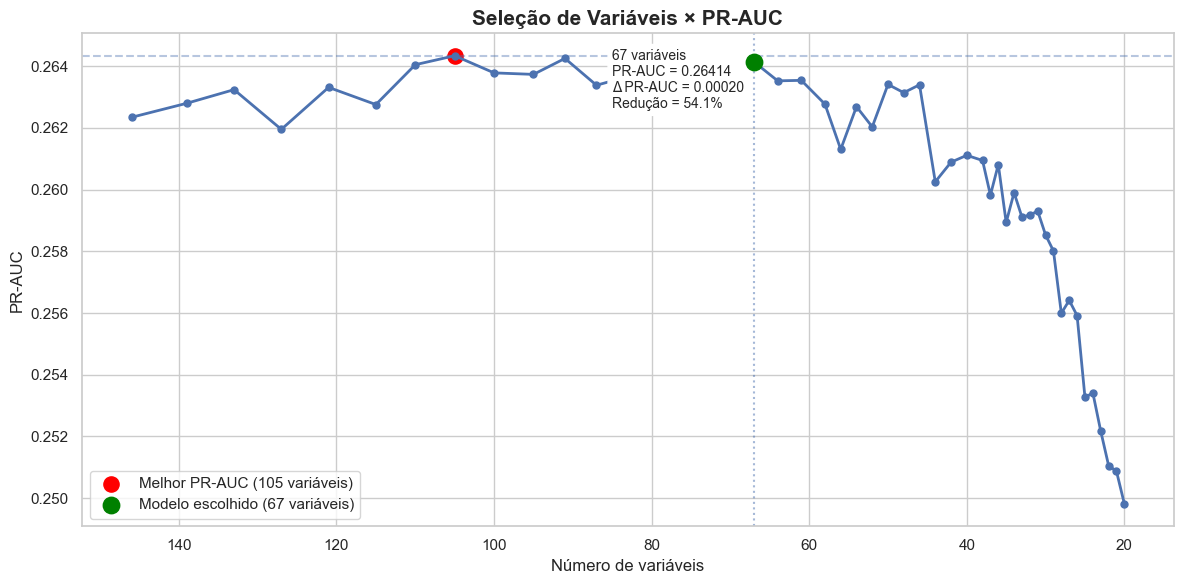

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

TOTAL_VARIAVEIS = 146

fig, ax = plt.subplots(figsize=(12, 6))

# ======================================================
# Linha principal
# ======================================================

ax.plot(
    historico["n_variaveis"],
    historico["pr_auc"],
    marker="o",
    linewidth=2,
    markersize=5,
)

# ======================================================
# Melhor resultado absoluto
# ======================================================

melhor_idx = historico["pr_auc"].idxmax()

melhor_n = historico.loc[melhor_idx, "n_variaveis"]
melhor_pr = historico.loc[melhor_idx, "pr_auc"]

ax.scatter(
    melhor_n,
    melhor_pr,
    color="red",
    s=120,
    label=f"Melhor PR-AUC ({melhor_n} variáveis)"
)

# ======================================================
# Modelo escolhido (67 variáveis)
# ======================================================

escolha_idx = historico[
    historico["n_variaveis"] == 67
].index[0]

escolha_n = historico.loc[
    escolha_idx,
    "n_variaveis"
]

escolha_pr = historico.loc[
    escolha_idx,
    "pr_auc"
]

ax.scatter(
    escolha_n,
    escolha_pr,
    color="green",
    s=140,
    zorder=6,
    label="Modelo escolhido (67 variáveis)"
)

# ======================================================
# Linhas auxiliares
# ======================================================

ax.axhline(
    melhor_pr,
    linestyle="--",
    alpha=0.4
)

ax.axvline(
    escolha_n,
    linestyle=":",
    alpha=0.5
)

# ======================================================
# Métricas
# ======================================================

pr_diff = melhor_pr - escolha_pr

reducao = (
    (TOTAL_VARIAVEIS - escolha_n)
    / TOTAL_VARIAVEIS
) * 100

texto = (
    f"{escolha_n} variáveis\n"
    f"PR-AUC = {escolha_pr:.5f}\n"
    f"Δ PR-AUC = {pr_diff:.5f}\n"
    f"Redução = {reducao:.1f}%"
)

ax.annotate(
    texto,
    xy=(escolha_n, escolha_pr),
    xytext=(85, escolha_pr - 0.0015),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10,
    bbox=dict(boxstyle="round", fc="white")
)

# ======================================================
# Layout
# ======================================================

ax.invert_xaxis()

ax.set_title(
    "Seleção de Variáveis × PR-AUC",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Número de variáveis")
ax.set_ylabel("PR-AUC")

ax.legend()

plt.tight_layout()
plt.show()

In [16]:
X_train_processado = X_train_processado[melhores_variaveis]
X_val_processado = X_val_processado[melhores_variaveis]
X_test_processado = X_test_processado[melhores_variaveis]

### Modelagem

In [17]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def criar_modelos(y_train):

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

    modelos = {

        "Random Forest": RandomForestClassifier(
            n_estimators=1000,
            criterion="gini",
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            bootstrap=True,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        ),

        "LightGBM": LGBMClassifier(
            objective="binary",
            boosting_type="gbdt",

            n_estimators=950,
            learning_rate=0.02,

            num_leaves=31,
            max_depth=-1,
            min_child_samples=50,

            subsample=0.8,
            subsample_freq=1,

            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            random_state=42,
            n_jobs=-1,
            verbose=-1,
        ),

        "XGBoost": XGBClassifier(
            objective="binary:logistic",

            n_estimators=600,
            learning_rate=0.03,

            max_depth=30,
            min_child_weight=5,
            gamma=0.1,

            subsample=0.8,
            colsample_bytree=0.8,
            colsample_bylevel=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            scale_pos_weight=scale_pos_weight,

            eval_metric="logloss",

            random_state=42,
            n_jobs=-1,
        ),
    }

    return modelos

In [19]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)


def calcular_metricas(y_true, y_pred, y_prob):
    """Calcula as métricas de classificação."""

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_SCORE": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "KS": ks,
    }

In [20]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
import pandas as pd


def avaliar_modelos_cv(
    X,
    y,
    modelos,
    n_splits=3,
):
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    resultados = []

    for nome, modelo_base in modelos.items():

        for idx_train, idx_val in cv.split(X, y):

            X_train_fold = X.iloc[idx_train]
            X_val_fold = X.iloc[idx_val]

            y_train_fold = y.iloc[idx_train]
            y_val_fold = y.iloc[idx_val]

            modelo = clone(modelo_base)

            # Atualiza o balanceamento apenas para modelos compatíveis
            if "scale_pos_weight" in modelo.get_params():

                scale_pos_weight = (
                    (y_train_fold == 0).sum()
                    /
                    (y_train_fold == 1).sum()
                )

                modelo.set_params(
                    scale_pos_weight=scale_pos_weight
                )

            modelo.fit(
                X_train_fold,
                y_train_fold,
            )

            y_pred = modelo.predict(X_val_fold)
            y_prob = modelo.predict_proba(X_val_fold)[:, 1]

            metricas = calcular_metricas(
                y_true=y_val_fold,
                y_pred=y_pred,
                y_prob=y_prob,
            )

            resultados.append({
                "Modelo": nome,
                **metricas,
            })

    resultados = pd.DataFrame(resultados)

    resumo = (
        resultados
        .groupby("Modelo")
        .agg(
            Precision_Mean=("Precision", "mean"),
            Precision_STD=("Precision", "std"),
            Recall_Mean=("Recall", "mean"),
            Recall_STD=("Recall", "std"),
            F1_Mean=("F1_SCORE", "mean"),
            F1_STD=("F1_SCORE", "std"),
            ROC_AUC_Mean=("ROC_AUC", "mean"),
            ROC_AUC_STD=("ROC_AUC", "std"),
            PR_AUC_Mean=("PR_AUC", "mean"),
            PR_AUC_STD=("PR_AUC", "std"),
            KS_Mean=("KS", "mean"),
            KS_STD=("KS", "std"),
        )
        .round(4)
        .reset_index()
    )

    return resumo

In [21]:
# Cria o dicionário de modelos
modelos = criar_modelos(y_train)

Scale Pos Weight: 11.39


In [22]:
import os

import mlflow
import pandas as pd

from sklearn.base import clone


mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI","http://localhost:5000"))
mlflow.set_experiment("models-cross-val")

resumos = []

with mlflow.start_run(run_name="cross-validation"):

    mlflow.set_tag("stage","model_selection")
    mlflow.set_tag("metric","PR_AUC")
    mlflow.log_param("n_splits",3)
    mlflow.log_param("n_features",X_train_processado.shape[1])

    for nome_modelo, modelo in modelos.items():

        with mlflow.start_run(run_name=nome_modelo,nested=True,):

            modelo_cv = clone(modelo)

            resumo = avaliar_modelos_cv(
                X=X_train_processado,
                y=y_train,
                modelos={
                    nome_modelo: modelo_cv
                },
                n_splits=3,
            )

            linha = resumo.iloc[0]

            mlflow.log_param("algorithm",nome_modelo)

            mlflow.log_metrics({

                "precision_mean": float(linha["Precision_Mean"]),
                "precision_std": float(linha["Precision_STD"]),

                "recall_mean": float(linha["Recall_Mean"]),
                "recall_std": float(linha["Recall_STD"]),

                "f1_mean": float(linha["F1_Mean"]),
                "f1_std": float(linha["F1_STD"]),

                "roc_auc_mean": float(linha["ROC_AUC_Mean"]),
                "roc_auc_std": float(linha["ROC_AUC_STD"]),

                "pr_auc_mean": float(linha["PR_AUC_Mean"]),
                "pr_auc_std": float(linha["PR_AUC_STD"]),

                "ks_mean": float(linha["KS_Mean"]),
                "ks_std": float(linha["KS_STD"]),
            })

            resumos.append(resumo)

resumo = (
    pd.concat(resumos)
      .sort_values(
          by="PR_AUC_Mean",
          ascending=False
      )
      .reset_index(drop=True)
)

resumo

🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/9eab7a961eed403d9eec00ecb124d054
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run LightGBM at: http://localhost:5000/#/experiments/1/runs/8588de09f00a497db89a2ea708c256d9
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/693f09c098b64cc8b5267e3bd7620878
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run cross-validation at: http://localhost:5000/#/experiments/1/runs/f2f43b99963a40b3862027aa50c63b36
🧪 View experiment at: http://localhost:5000/#/experiments/1


,Modelo,Precision_Mean,Precision_STD,Recall_Mean,Recall_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,PR_AUC_Mean,PR_AUC_STD,KS_Mean,KS_STD
0,LightGBM,0.1923,0.0014,0.6401,0.0035,0.2957,0.0018,0.7739,0.0014,0.2641,0.0029,0.4138,0.0019
1,XGBoost,0.4438,0.0082,0.0960,0.0035,0.1579,0.0045,0.7665,0.0012,0.2560,0.0010,0.4009,0.0014
2,Random Forest,0.2142,0.0018,0.4865,0.0074,0.2974,0.0028,0.7553,0.0010,0.2349,0.0015,0.3853,0.0026


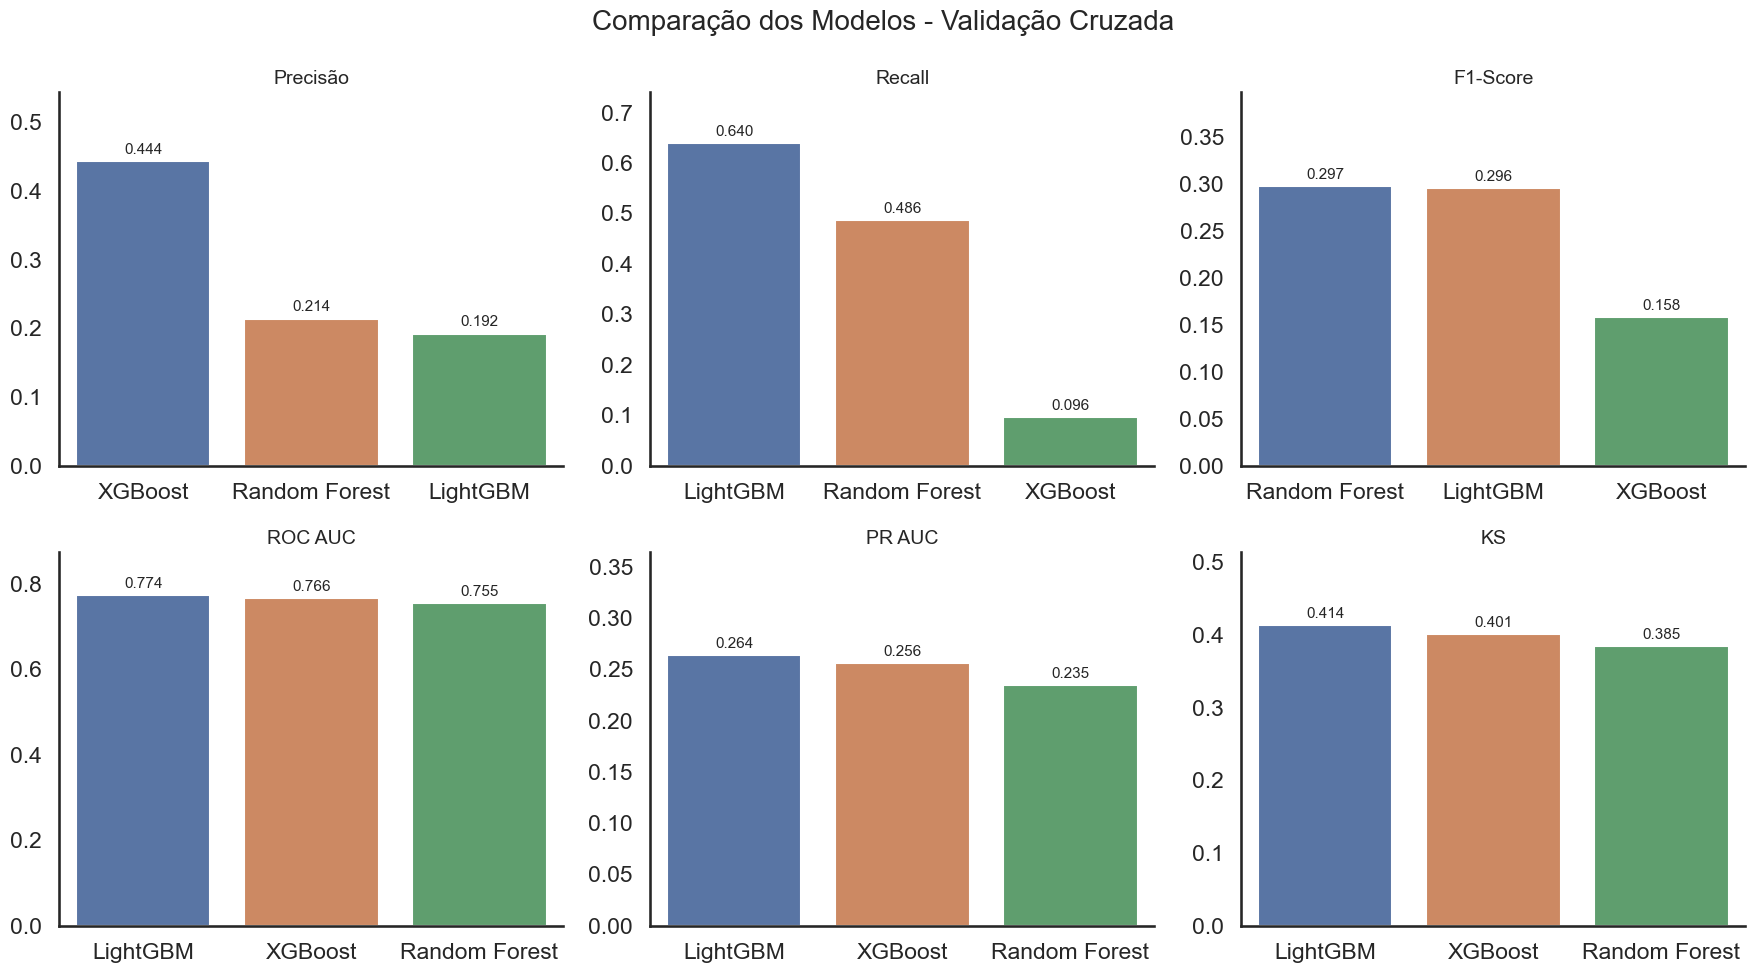

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk",
    palette="deep",
)

metricas = [
    ("Precision", "Precisão"),
    ("Recall", "Recall"),
    ("F1", "F1-Score"),
    ("ROC_AUC", "ROC AUC"),
    ("PR_AUC", "PR AUC"),
    ("KS", "KS"),
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10),
)

axes = axes.flatten()

for ax, (metrica, titulo) in zip(axes, metricas):

    # Ordena os modelos do melhor para o pior
    dados_plot = resumo.sort_values(
        by=f"{metrica}_Mean",
        ascending=False,
    )

    sns.barplot(
        data=dados_plot,
        x="Modelo",
        y=f"{metrica}_Mean",
        ax=ax,
    )

    # Valores acima das barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=3,
            fontsize=11,
        )

    ax.set_title(
        titulo,
        fontsize=14,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_ylim(
        0,
        min(1.0, dados_plot[f"{metrica}_Mean"].max() + 0.10)
    )

    # Remove grade
    ax.grid(False)

    # Remove bordas superior e direita
    sns.despine(ax=ax)

plt.suptitle(
    "Comparação dos Modelos - Validação Cruzada",
    fontsize=20,
)

plt.tight_layout()

plt.show()

In [24]:
import os
import mlflow
import pandas as pd
from sklearn.base import clone

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI","http://localhost:5000"))
mlflow.set_experiment("selection-model-win")

resultados = []

with mlflow.start_run(run_name="test-set-evaluation"):

    mlflow.set_tag("stage","test_evaluation")
    mlflow.set_tag("selection_metric","PR_AUC")
    mlflow.log_param("n_features",X_train_processado.shape[1])

    for nome_modelo, modelo_base in modelos.items():

        with mlflow.start_run(run_name=nome_modelo,nested=True,):

            modelo = clone(modelo_base)
            if "scale_pos_weight" in modelo.get_params():

                modelo.set_params(
                    scale_pos_weight=(
                        (y_train == 0).sum()
                        /
                        (y_train == 1).sum()
                    )
                )

            modelo.fit(X_train_processado,y_train)
            y_pred = modelo.predict(X_test_processado)
            y_prob = modelo.predict_proba(X_test_processado)[:, 1]

            metricas = calcular_metricas(y_true=y_test,y_pred=y_pred,y_prob=y_prob,)

            mlflow.log_param("algorithm",nome_modelo)
            mlflow.log_metrics({

                "precision": float(metricas["Precision"]),
                "recall": float(metricas["Recall"]),
                "f1_score": float(metricas["F1_SCORE"]),
                "roc_auc": float(metricas["ROC_AUC"]),
                "pr_auc": float(metricas["PR_AUC"]),
                "ks": float(metricas["KS"]),

            })

            resultados.append({"Modelo": nome_modelo,**metricas})

resultado_teste = (
    pd.DataFrame(resultados)
      .sort_values(
          by="PR_AUC",
          ascending=False
      )
      .reset_index(drop=True)
)

modelo_campeao = resultado_teste.loc[0, "Modelo"]
print(f"Modelo campeão: {modelo_campeao}")
resultado_teste

🏃 View run Random Forest at: http://localhost:5000/#/experiments/2/runs/8f62105e841441949cdc72f70ff325a2
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run LightGBM at: http://localhost:5000/#/experiments/2/runs/8adcd363aa6147c2a85f003b89ed2df0
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run XGBoost at: http://localhost:5000/#/experiments/2/runs/316207aca94340cdb3b08b998b5a2ae8
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run test-set-evaluation at: http://localhost:5000/#/experiments/2/runs/6f6ef3e9cb594fa08e5338372dc8cf21
🧪 View experiment at: http://localhost:5000/#/experiments/2
Modelo campeão: LightGBM


,Modelo,Precision,Recall,F1_SCORE,ROC_AUC,PR_AUC,KS
0,LightGBM,0.189023,0.667271,0.294594,0.778473,0.277141,0.421111
1,XGBoost,0.454459,0.096475,0.159163,0.770696,0.261780,0.406721
2,Random Forest,0.208394,0.518026,0.297221,0.757084,0.240071,0.387584


In [25]:
modelos_treinados = {}

for nome, modelo in modelos.items():

    modelo = clone(modelo)

    if "scale_pos_weight" in modelo.get_params():

        scale_pos_weight = (
            (y_train == 0).sum()
            /
            (y_train == 1).sum()
        )

        modelo.set_params(scale_pos_weight=scale_pos_weight)

    modelo.fit(X_train_processado,y_train,)
    modelos_treinados[nome] = modelo

c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\eduar\AppData\Local\Temp\ipykernel_16772\4012328325.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()

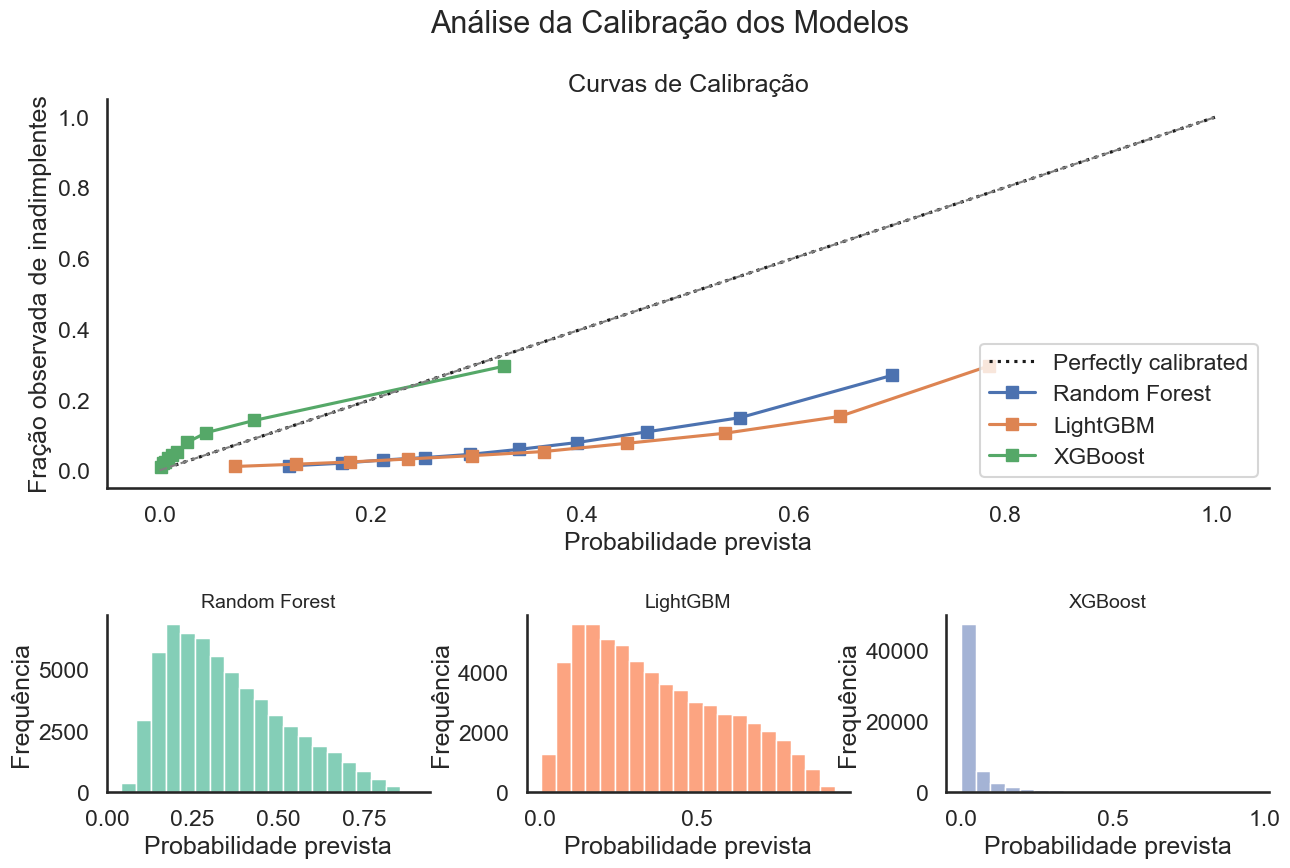


Brier Score (quanto menor, melhor):


,Modelo,Brier Score
0,XGBoost,0.069199
1,Random Forest,0.150105
2,LightGBM,0.170977


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

sns.set_theme(
    style="white",
    context="talk"
)

cores = sns.color_palette("Set2", len(modelos_treinados))

fig = plt.figure(figsize=(15, 9))

# ============================
# Layout
# ============================
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[2.2, 1],
    hspace=0.45,
    wspace=0.30,
)

# ============================
# Curvas de calibração
# ============================
ax_cal = fig.add_subplot(gs[0, :])

brier_scores = []

for cor, (nome, modelo) in zip(cores, modelos_treinados.items()):

    y_prob = modelo.predict_proba(X_test_processado)[:, 1]

    # Brier Score
    brier = brier_score_loss(
        y_test,
        y_prob,
    )

    brier_scores.append({
        "Modelo": nome,
        "Brier Score": brier,
    })

    CalibrationDisplay.from_predictions(
        y_true=y_test,
        y_prob=y_prob,
        n_bins=10,
        strategy="quantile",
        name=nome,
        ax=ax_cal,
    )

# Linha de calibração perfeita
ax_cal.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=1.5,
)

ax_cal.set_title(
    "Curvas de Calibração",
    fontsize=18,
)

ax_cal.set_xlabel("Probabilidade prevista")
ax_cal.set_ylabel("Fração observada de inadimplentes")

ax_cal.grid(False)
sns.despine(ax=ax_cal)

# ============================
# Histogramas das probabilidades
# ============================
for i, (cor, (nome, modelo)) in enumerate(
    zip(cores, modelos_treinados.items())
):

    ax = fig.add_subplot(gs[1, i])

    y_prob = modelo.predict_proba(X_test_processado)[:, 1]

    sns.histplot(
        y_prob,
        bins=20,
        color=cor,
        alpha=0.80,
        edgecolor=None,
        ax=ax,
    )

    ax.set_title(nome, fontsize=14)
    ax.set_xlabel("Probabilidade prevista")
    ax.set_ylabel("Frequência")

    ax.grid(False)
    sns.despine(ax=ax)

# ============================
# Título geral
# ============================
plt.suptitle(
    "Análise da Calibração dos Modelos",
    fontsize=22,
)

plt.tight_layout()

plt.show()

# ============================
# Brier Score
# ============================

brier_scores = (
    pd.DataFrame(brier_scores)
    .sort_values(
        by="Brier Score",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("\nBrier Score (quanto menor, melhor):")
brier_scores

**Análise**

Com base no resultado dos modelos, o lightGBM será o modelo campeão. Ele é o modelo com melhor capacidade discriminativa. Ele lidera em Recall, ROC AUC, PR AUC e KS, que são métricas centrais para avaliar a separação entre bons e maus pagadores. Como o projeto tem e premissa de um modelo que tenha uma performance maior para separar as classes, esse é o modelo escolhido. Agora, será realizado a otimização de hiperparâmetros utilizando o Optuna, usando uma abordagem multivariada. Logo depois dessa etapa, será utilizado o cálculo do threhsold para o modelo otimizado.

### Otimização de hiperparâmetros

In [32]:
print(study.best_params)

{'learning_rate': 0.015571426505875839, 'n_estimators': 1500, 'num_leaves': 24, 'min_child_samples': 128, 'subsample': 0.9090295739977976, 'colsample_bytree': 0.8999415804553264, 'reg_alpha': 4.6297741088726654e-07, 'reg_lambda': 3.249115484535142e-06, 'min_split_gain': 0.7978851525211049, 'scale_pos_weight': 6.249791712518849}


In [28]:
from lightgbm import LGBMClassifier

modelo_final = LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",

        n_estimators=950,
        learning_rate=0.02,

        num_leaves=31,
        max_depth=-1,
        min_child_samples=50,

        subsample=0.8,
        subsample_freq=1,

        colsample_bytree=0.8,

        reg_alpha=0.1,
        reg_lambda=1.0,

        scale_pos_weight=scale_pos_weight,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

modelo_final.set_params(
    scale_pos_weight=(
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )
)

modelo_final.fit(X_train_processado,y_train,)
y_pred = modelo_final.predict(X_test_processado)
y_prob = modelo_final.predict_proba(X_test_processado)[:, 1]

# ==========================================
# Métricas
# ==========================================

metricas = calcular_metricas(
    y_true=y_test,
    y_pred=y_pred,
    y_prob=y_prob,
)

metricas = (pd.DataFrame(metricas, index=["LightGBM"]).T)
metricas

2026/07/26 08:17:35 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '841fc771beaf4b1fa4cd4cef12909aef', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
2026/07/26 08:17:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run overjoyed-hog-168 at: http://localhost:5000/#/experiments/3/runs/841fc771beaf4b1fa4cd4cef12909aef
🧪 View experiment at: http://localhost:5000/#/experiments/3


,LightGBM
Precision,0.189023
Recall,0.667271
F1_SCORE,0.294594
ROC_AUC,0.778473
PR_AUC,0.277141
KS,0.421111


c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\eduar\AppData\Local\Temp\ipykernel_16772\2104838352.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


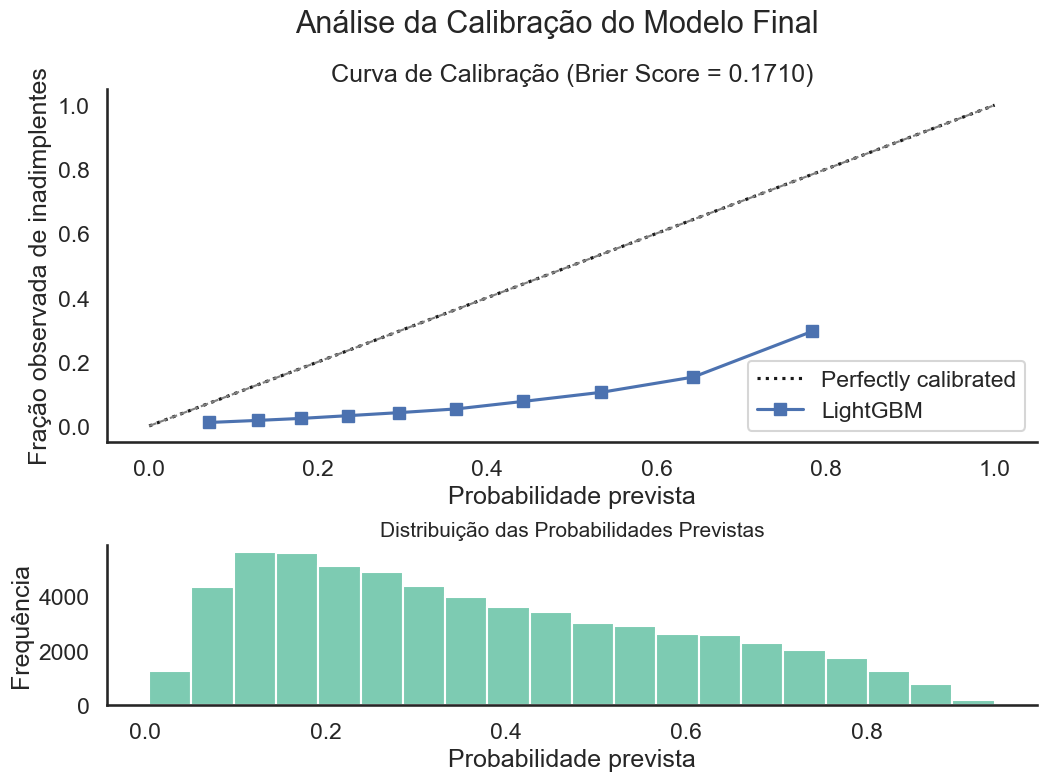

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

sns.set_theme(
    style="white",
    context="talk"
)

fig = plt.figure(figsize=(12, 8))

# ============================
# Layout
# ============================

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[2.2, 1],
    hspace=0.40,
)

# ============================
# Curva de calibração
# ============================

ax_cal = fig.add_subplot(gs[0])

CalibrationDisplay.from_predictions(
    y_true=y_test,
    y_prob=y_prob,
    n_bins=10,
    strategy="quantile",
    name="LightGBM",
    ax=ax_cal,
)

ax_cal.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=1.5,
)

brier = brier_score_loss(
    y_test,
    y_prob,
)

ax_cal.set_title(
    f"Curva de Calibração (Brier Score = {brier:.4f})",
    fontsize=18,
)

ax_cal.set_xlabel(
    "Probabilidade prevista"
)

ax_cal.set_ylabel(
    "Fração observada de inadimplentes"
)

ax_cal.grid(False)
sns.despine(ax=ax_cal)

# ============================
# Histograma das probabilidades
# ============================

ax_hist = fig.add_subplot(gs[1])

sns.histplot(
    y_prob,
    bins=20,
    color=sns.color_palette("Set2")[0],
    alpha=0.85,
    edgecolor=None,
    ax=ax_hist,
)

ax_hist.set_title(
    "Distribuição das Probabilidades Previstas",
    fontsize=15,
)

ax_hist.set_xlabel(
    "Probabilidade prevista"
)

ax_hist.set_ylabel(
    "Frequência"
)

ax_hist.grid(False)
sns.despine(ax=ax_hist)

# ============================
# Título geral
# ============================

plt.suptitle(
    "Análise da Calibração do Modelo Final",
    fontsize=22,
)

plt.tight_layout()

plt.show()

c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\eduar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

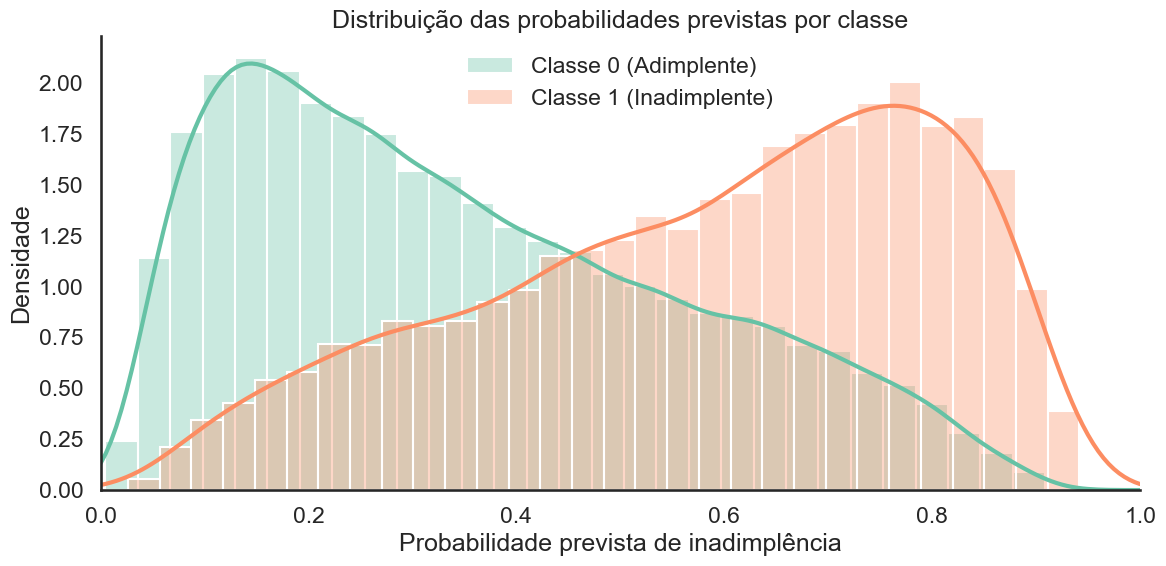

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    context="talk"
)

cores = sns.color_palette("Set2")

fig, ax = plt.subplots(figsize=(12, 6))

# ==========================================
# Histograma - Classe 0
# ==========================================

sns.histplot(
    y_prob[y_test == 0],
    bins=30,
    stat="density",
    color=cores[0],
    alpha=0.35,
    edgecolor=None,
    label="Classe 0 (Adimplente)",
    ax=ax,
)

# KDE - Classe 0
sns.kdeplot(
    y_prob[y_test == 0],
    color=cores[0],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Histograma - Classe 1
# ==========================================

sns.histplot(
    y_prob[y_test == 1],
    bins=30,
    stat="density",
    color=cores[1],
    alpha=0.35,
    edgecolor=None,
    label="Classe 1 (Inadimplente)",
    ax=ax,
)

# KDE - Classe 1
sns.kdeplot(
    y_prob[y_test == 1],
    color=cores[1],
    linewidth=3,
    clip=(0, 1),
    ax=ax,
)

# ==========================================
# Configurações
# ==========================================

ax.set_xlim(0, 1)

ax.set_xlabel(
    "Probabilidade prevista de inadimplência"
)

ax.set_ylabel(
    "Densidade"
)

ax.set_title(
    "Distribuição das probabilidades previstas por classe",
    fontsize=18,
)

ax.legend(
    frameon=False
)

ax.grid(False)

sns.despine()

plt.tight_layout()

plt.show()

### Se analisarmos apenas os 10% clientes com maior score de risco, quantas vezes mais inadimplentes encontraremos em relação à média da carteira?

In [31]:
import numpy as np
import pandas as pd

resultado = pd.DataFrame({
    "target": y_test,
    "score": y_prob,
})

# Decis (1 = maior risco)
resultado["decil"] = pd.qcut(
    resultado["score"],
    q=10,
    labels=False,
    duplicates="drop",
)

resultado["decil"] = 10 - resultado["decil"]

taxa_global = resultado["target"].mean()

lift = (
    resultado
    .groupby("decil")
    .agg(
        Clientes=("target", "count"),
        Maus=("target", "sum"),
        Taxa_Maus=("target", "mean"),
    )
    .sort_index()
)

lift["Lift"] = (
    lift["Taxa_Maus"] /
    taxa_global
)

lift["Lift Acumulado"] = (
    lift["Maus"].cumsum()
    /
    lift["Clientes"].cumsum()
) / taxa_global

lift = lift.round(3)

lift

,Clientes,Maus,Taxa_Maus,Lift,Lift Acumulado
decil,,,,,
1,6151,1814,0.295,3.653,3.653
2,6150,937,0.152,1.887,2.770
3,6150,645,0.105,1.299,2.280
4,6150,471,0.077,0.949,1.947
5,6150,327,0.053,0.659,1.689
6,6151,255,0.041,0.514,1.493
7,6150,197,0.032,0.397,1.337
8,6150,145,0.024,0.292,1.206
9,6150,107,0.017,0.216,1.096


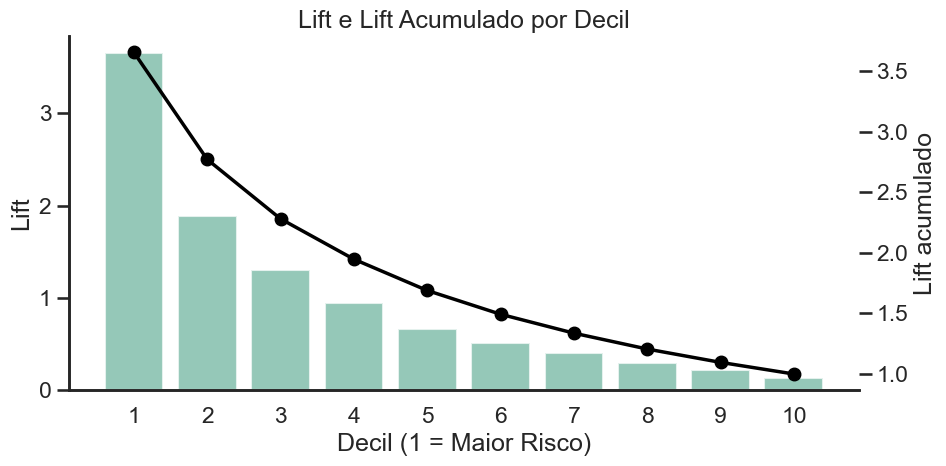

In [32]:
fig, ax = plt.subplots(figsize=(10,5))

sns.barplot(
    data=lift.reset_index(),
    x="decil",
    y="Lift",
    color=sns.color_palette("Set2")[0],
    alpha=0.75,
    ax=ax,
)

ax2 = ax.twinx()

ax2.plot(
    lift.index.astype(str),
    lift["Lift Acumulado"],
    marker="o",
    linewidth=2.5,
    color="black",
)

ax.set_ylabel("Lift")
ax2.set_ylabel("Lift acumulado")

ax.set_xlabel("Decil (1 = Maior Risco)")

ax.set_title(
    "Lift e Lift Acumulado por Decil",
    fontsize=18,
)

sns.despine()

plt.tight_layout()

plt.show()

O primeiro decil apresentou Lift igual a 3,48, indicando que a concentração de inadimplentes entre os 10% clientes com maior score é 3,48 vezes superior à taxa média de inadimplência da carteira. Esse resultado demonstra que o modelo possui boa capacidade de ordenação do risco, concentrando a maior parte dos eventos nas primeiras posições do ranking.

In [33]:
import pandas as pd

def tabela_decis(y_true, y_prob):
    df = pd.DataFrame({
        "target": y_true,
        "score": y_prob
    })

    df = df.sort_values("score", ascending=False)

    df["decil"] = pd.qcut(
        df.index,
        10,
        labels=False
    ) + 1

    resumo = (
        df.groupby("decil")
        .agg(
            taxa_eventos=("target", "mean"),
            quantidade=("target", "size"),
            eventos=("target", "sum")
        )
        .reset_index()
    )

    resumo["taxa_eventos"] *= 100

    return resumo

In [34]:
y_prob_train = modelo_final.predict_proba(X_train_processado)[:, 1]
y_prob_test = modelo_final.predict_proba(X_test_processado)[:, 1]

In [35]:
treino = tabela_decis(y_train, y_prob_train)
teste = tabela_decis(y_test, y_prob_test)

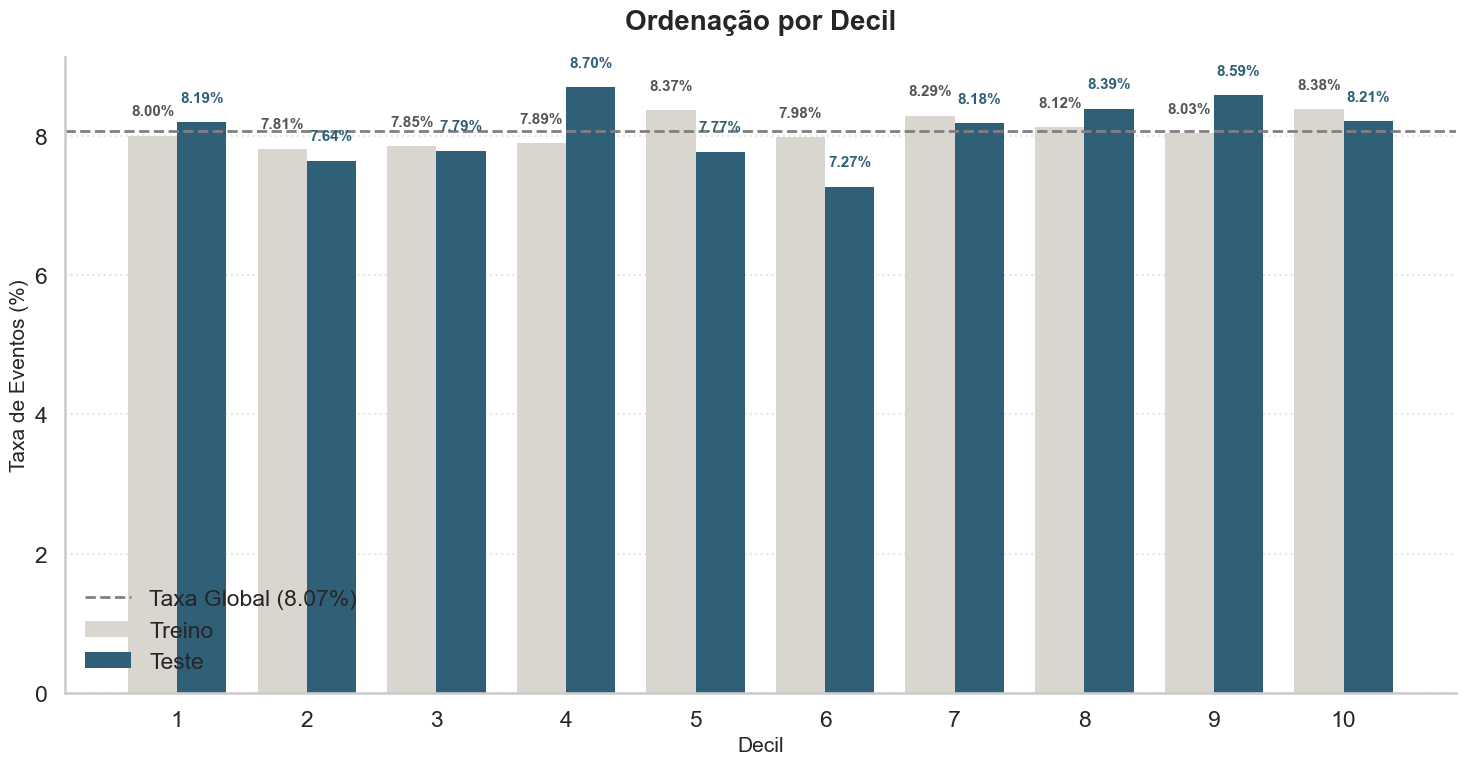

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk"
)

fig, ax = plt.subplots(figsize=(15, 8))

cores = ["#d9d6cf", "#2f6078"]

x = np.arange(len(treino))
width = 0.38

bars_train = ax.bar(
    x - width/2,
    treino["taxa_eventos"],
    width,
    color=cores[0],
    label="Treino",
    edgecolor="none"
)

bars_test = ax.bar(
    x + width/2,
    teste["taxa_eventos"],
    width,
    color=cores[1],
    label="Teste",
    edgecolor="none"
)

# Valores sobre as barras
for bar in bars_train:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color="#555555",
        fontweight="bold"
    )

for bar in bars_test:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.25,
        f"{h:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=cores[1],
        fontweight="bold"
    )

taxa_global = y_train.mean() * 100

ax.axhline(
    taxa_global,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Taxa Global ({taxa_global:.2f}%)"
)

ax.set_xticks(x)
ax.set_xticklabels(np.arange(1,11))

ax.set_xlabel("Decil", fontsize=15)
ax.set_ylabel("Taxa de Eventos (%)", fontsize=15)

ax.set_title(
    "Ordenação por Decil",
    fontsize=20,
    weight="bold",
    pad=20
)

ax.legend(frameon=False)
sns.despine()
ax.grid(axis="x", visible=False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

# ======================================================
# Probabilidades
# ======================================================

y_prob_val = modelo_final.predict_proba(
    X_val_processado
)[:, 1]

# ======================================================
# Curva Precision-Recall
# ======================================================

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_prob_val,
)

# ======================================================
# F1 para cada threshold
# ======================================================

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    /
    (precision[:-1] + recall[:-1] + 1e-12)
)

# ======================================================
# DataFrame com todos os thresholds
# ======================================================

metricas_threshold = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1_score": f1_scores,
})

metricas_threshold = metricas_threshold.sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

# ======================================================
# Melhor threshold
# ======================================================

melhor = metricas_threshold.iloc[0]

print("=" * 50)
print("Melhor Threshold")
print("=" * 50)

print(f"Threshold : {melhor['threshold']:.4f}")
print(f"Precision: {melhor['precision']:.4f}")
print(f"Recall   : {melhor['recall']:.4f}")
print(f"F1-score : {melhor['f1_score']:.4f}")

# ======================================================
# Top 20 thresholds
# ======================================================

metricas_threshold.head(20)

Melhor Threshold
Threshold : 0.6478
Precision: 0.2484
Recall   : 0.4640
F1-score : 0.3236


,threshold,precision,recall,f1_score
0,0.647806,0.248383,0.463998,0.323560
1,0.647731,0.248349,0.463998,0.323532
2,0.647727,0.248316,0.463998,0.323504
3,0.647876,0.248382,0.463746,0.323498
4,0.647694,0.248282,0.463998,0.323475
5,0.647866,0.248348,0.463746,0.323470
6,0.647550,0.248183,0.464250,0.323452
7,0.648494,0.248614,0.462739,0.323449
8,0.647685,0.248249,0.463998,0.323447
9,0.647837,0.248315,0.463746,0.323442


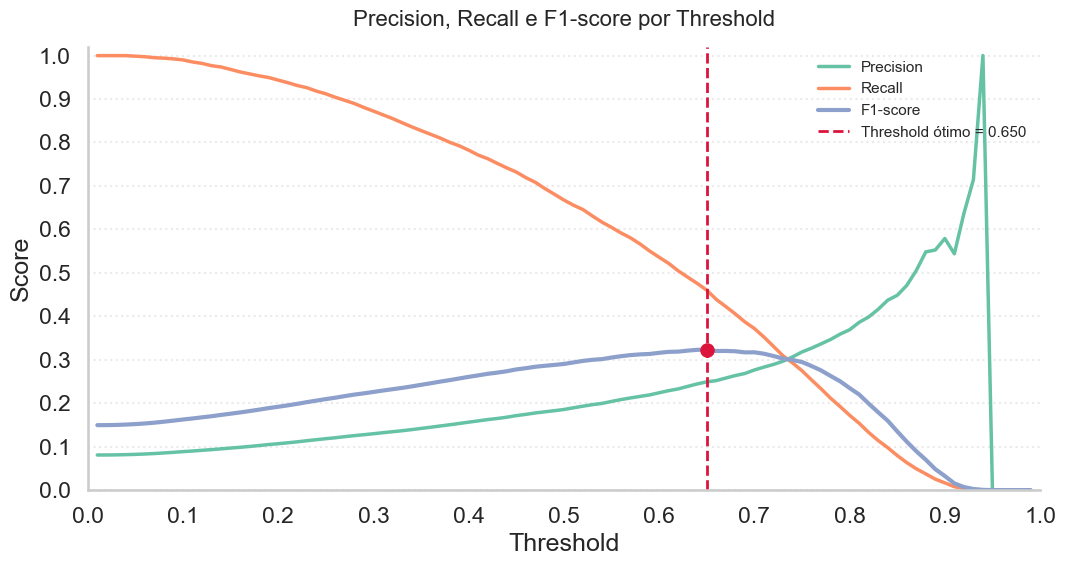

Threshold ótimo: 0.6500
F1 máximo: 0.3232


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)

# ============================
# Configuração do gráfico
# ============================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

# ============================
# Probabilidades da validação
# ============================

y_prob_val = modelo_final.predict_proba(X_val_processado)[:, 1]

# ============================
# Avaliação para vários thresholds
# ============================

thresholds = np.linspace(0.01, 0.99, 99)

precision = []
recall = []
f1 = []

for threshold in thresholds:

    y_pred = (y_prob_val >= threshold).astype(int)

    precision.append(
        precision_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    recall.append(
        recall_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

    f1.append(
        f1_score(
            y_val,
            y_pred,
            zero_division=0
        )
    )

precision = np.array(precision)
recall = np.array(recall)
f1 = np.array(f1)

# ============================
# Melhor threshold
# ============================

idx_best = np.argmax(f1)

best_threshold = thresholds[idx_best]
best_f1 = f1[idx_best]

# ============================
# Gráfico
# ============================

fig, ax = plt.subplots(figsize=(11, 6))

cores = sns.color_palette("Set2", 3)

ax.plot(
    thresholds,
    precision,
    linewidth=2.5,
    color=cores[0],
    label="Precision"
)

ax.plot(
    thresholds,
    recall,
    linewidth=2.5,
    color=cores[1],
    label="Recall"
)

ax.plot(
    thresholds,
    f1,
    linewidth=3,
    color=cores[2],
    label="F1-score"
)

# Threshold ótimo

ax.axvline(
    best_threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ótimo = {best_threshold:.3f}"
)

ax.scatter(
    best_threshold,
    best_f1,
    s=80,
    color="crimson",
    zorder=5
)

# Configurações

ax.set_title(
    "Precision, Recall e F1-score por Threshold",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

ax.grid(
    axis="x",
    visible=False
)

sns.despine()

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

print(f"Threshold ótimo: {best_threshold:.4f}")
print(f"F1 máximo: {best_f1:.4f}")

### Análise de negócio

In [39]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

# ======================================================
# Probabilidades no conjunto de teste
# ======================================================

y_prob_test = modelo_final.predict_proba(
    X_test_processado
)[:, 1]

# Predição usando o threshold escolhido na validação
y_pred_test = (
    y_prob_test >= best_threshold
).astype(int)

# Base para análise
resultado = X_test.copy()

resultado["TARGET"] = y_test.values
resultado["PROB"] = y_prob_test
resultado["PRED"] = y_pred_test

In [40]:
thresholds = np.arange(0.01, 1.00, 0.01)

dados = []

valor_total_default = resultado.loc[
    resultado["TARGET"] == 1,
    "AMT_CREDIT"
].sum()

for th in thresholds:

    pred = (resultado["PROB"] >= th).astype(int)

    precision = precision_score(
        resultado["TARGET"],
        pred,
        zero_division=0
    )

    recall = recall_score(
        resultado["TARGET"],
        pred,
    )

    f1 = f1_score(
        resultado["TARGET"],
        pred,
        zero_division=0
    )

    tp = resultado[
        (resultado["TARGET"] == 1) &
        (pred == 1)
    ]

    fp = resultado[
        (resultado["TARGET"] == 0) &
        (pred == 1)
    ]

    fn = resultado[
        (resultado["TARGET"] == 1) &
        (pred == 0)
    ]

    dados.append({

        "threshold": th,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "tp_valor": tp["AMT_CREDIT"].sum(),

        "fp_valor": fp["AMT_CREDIT"].sum(),

        "fn_valor": fn["AMT_CREDIT"].sum(),

        "captura_valor":

            tp["AMT_CREDIT"].sum()
            /
            valor_total_default

    })

metricas_financeiras = pd.DataFrame(dados)

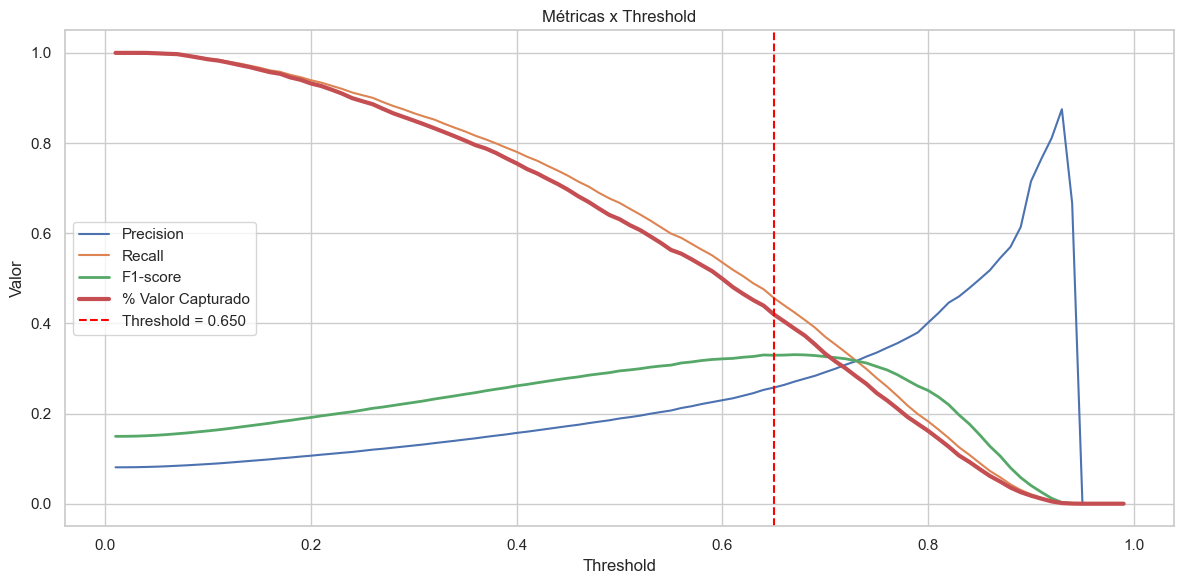

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

plt.plot(
    metricas_financeiras["threshold"],
    metricas_financeiras["precision"],
    label="Precision"
)

plt.plot(
    metricas_financeiras["threshold"],
    metricas_financeiras["recall"],
    label="Recall"
)

plt.plot(
    metricas_financeiras["threshold"],
    metricas_financeiras["f1"],
    label="F1-score",
    linewidth=2
)

plt.plot(
    metricas_financeiras["threshold"],
    metricas_financeiras["captura_valor"],
    label="% Valor Capturado",
    linewidth=3
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {best_threshold:.3f}"
)

plt.xlabel("Threshold")

plt.ylabel("Valor")

plt.title(
    "Métricas x Threshold"
)

plt.legend()

plt.tight_layout()

plt.show()

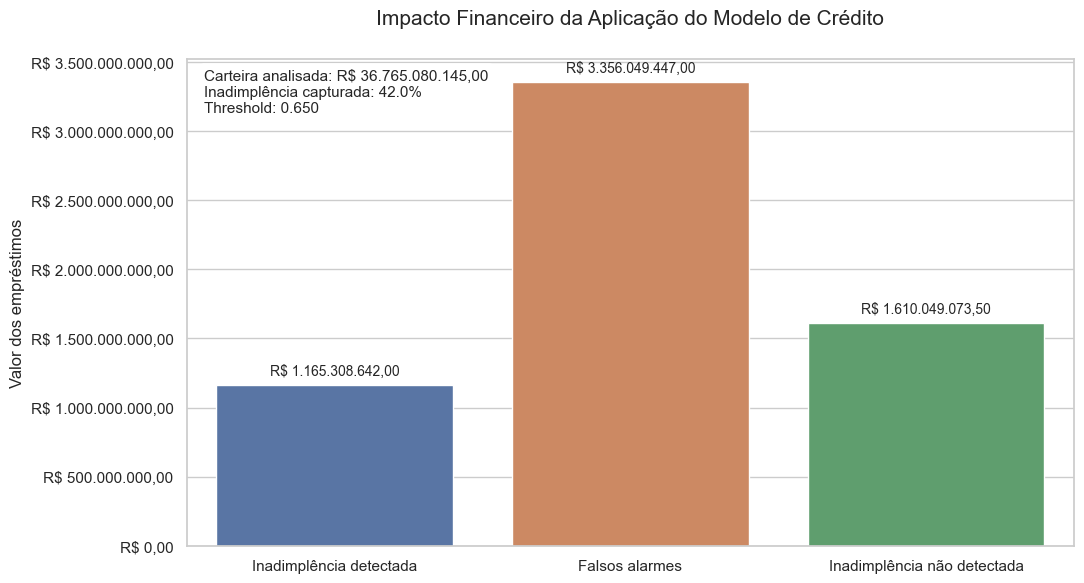

RESUMO FINANCEIRO
Carteira analisada..............: R$ 36.765.080.145,00
Valor total inadimplente........: R$ 2.775.357.715,50
Inadimplência detectada.........: R$ 1.165.308.642,00
Falsos alarmes.................: R$ 3.356.049.447,00
Inadimplência não detectada.....: R$ 1.610.049.073,50
Percentual do valor capturado...: 41.99%


In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pred = (resultado["PROB"] >= best_threshold).astype(int)

tp = resultado[(resultado["TARGET"] == 1) & (pred == 1)]
fp = resultado[(resultado["TARGET"] == 0) & (pred == 1)]
fn = resultado[(resultado["TARGET"] == 1) & (pred == 0)]

valores = pd.DataFrame({
    "Categoria": [
        "Inadimplência detectada",
        "Falsos alarmes",
        "Inadimplência não detectada"
    ],
    "Valor": [
        tp["AMT_CREDIT"].sum(),
        fp["AMT_CREDIT"].sum(),
        fn["AMT_CREDIT"].sum()
    ]
})

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(data=valores, x="Categoria", y="Valor", ax=ax)

def formato_real(x, pos):
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(formato_real))

for barra in ax.patches:
    valor = barra.get_height()

    ax.annotate(
        formato_real(valor, None),
        (barra.get_x() + barra.get_width() / 2, valor),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 5),
        textcoords="offset points"
    )

valor_total = resultado["AMT_CREDIT"].sum()
valor_tp = tp["AMT_CREDIT"].sum()
valor_fp = fp["AMT_CREDIT"].sum()
valor_fn = fn["AMT_CREDIT"].sum()

valor_total_inadimplencia = resultado.loc[
    resultado["TARGET"] == 1,
    "AMT_CREDIT"
].sum()

percentual_capturado = valor_tp / valor_total_inadimplencia

ax.text(
    0.02,
    0.98,
    f"Carteira analisada: {formato_real(valor_total, None)}\n"
    f"Inadimplência capturada: {percentual_capturado:.1%}\n"
    f"Threshold: {best_threshold:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.95)
)

ax.set_title(
    "Impacto Financeiro da Aplicação do Modelo de Crédito",
    fontsize=15,
    pad=25
)

ax.set_xlabel("")
ax.set_ylabel("Valor dos empréstimos")

plt.tight_layout()
plt.show()

print("=" * 70)
print("RESUMO FINANCEIRO")
print("=" * 70)
print(f"Carteira analisada..............: {formato_real(valor_total, None)}")
print(f"Valor total inadimplente........: {formato_real(valor_total_inadimplencia, None)}")
print(f"Inadimplência detectada.........: {formato_real(valor_tp, None)}")
print(f"Falsos alarmes.................: {formato_real(valor_fp, None)}")
print(f"Inadimplência não detectada.....: {formato_real(valor_fn, None)}")
print(f"Percentual do valor capturado...: {percentual_capturado:.2%}")

### O modelo está encontrando os maiores riscos financeiros ou apenas muitos contratos pequenos?

In [44]:
from sklearn.metrics import precision_score, recall_score

df_analise = X_test.copy()

df_analise["target"] = y_test.values
df_analise["probabilidade"] = y_prob_test
df_analise["predicao"] = y_pred_test

In [45]:
y_pred_test = (y_prob_test >= threshold).astype(int)

In [46]:
df_analise["faixa_credito"] = pd.qcut(
    df_analise["AMT_CREDIT"],
    q=10,
    labels=[f"Decil {i}" for i in range(1, 11)]
)

In [50]:
resultado = []

valor_inad_total = df_analise.loc[
    df_analise["target"] == 1,
    "AMT_CREDIT"
].sum()

for faixa, grupo in df_analise.groupby("faixa_credito", observed=True):

    qtd_inad = (grupo["target"] == 1).sum()

    valor_total = grupo["AMT_CREDIT"].sum()

    valor_inad = grupo.loc[
        grupo["target"] == 1,
        "AMT_CREDIT"
    ].sum()

    valor_detectado = grupo.loc[
        (grupo["target"] == 1) &
        (grupo["predicao"] == 1),
        "AMT_CREDIT"
    ].sum()

    resultado.append({
        "Faixa": faixa,
        "Clientes": len(grupo),
        "Inadimplentes": qtd_inad,
        "Valor Médio": grupo["AMT_CREDIT"].mean(),
        "Valor Total": valor_total,
        "Valor Inadimplente": valor_inad,
        "% da Inadimplência Total": valor_inad / valor_inad_total,
        "Ticket Médio Inadimplente": (
            valor_inad / qtd_inad if qtd_inad > 0 else 0
        ),
        "Taxa Inadimplência": grupo["target"].mean(),
        "Recall": recall_score(
            grupo["target"],
            grupo["predicao"],
            zero_division=0
        ),
        "Precision": precision_score(
            grupo["target"],
            grupo["predicao"],
            zero_division=0
        ),
        "Valor Capturado": valor_detectado,
        "% Valor Capturado": (
            valor_detectado / valor_inad
            if valor_inad > 0 else 0
        )
    })

resultado = pd.DataFrame(resultado)

resultado

,Faixa,Clientes,Inadimplentes,Valor Médio,Valor Total,Valor Inadimplente,% da Inadimplência Total,Ticket Médio Inadimplente,Taxa Inadimplência,Recall,Precision,Valor Capturado,% Valor Capturado
0,Decil 1,6603,442,1.378304e+05,9.100939e+08,62749602.0,0.022610,1.419674e+05,0.066939,0.393665,0.237057,25399107.0,0.404769
1,Decil 2,6421,489,2.283760e+05,1.466402e+09,111724182.0,0.040256,2.284748e+05,0.076156,0.443763,0.248000,49929340.5,0.446898
2,Decil 3,5431,456,2.775944e+05,1.507615e+09,127333170.0,0.045880,2.792394e+05,0.083962,0.504386,0.272835,64479955.5,0.506388
3,Decil 4,6165,596,3.577816e+05,2.205724e+09,212706126.0,0.076641,3.568895e+05,0.096675,0.558725,0.256351,119526021.0,0.561930
4,Decil 5,6155,560,4.687545e+05,2.885184e+09,260993493.0,0.094040,4.660598e+05,0.090983,0.519643,0.247449,134759173.5,0.516332
5,Decil 6,6195,678,5.520624e+05,3.420026e+09,375146239.5,0.135170,5.533130e+05,0.109443,0.576696,0.287500,216546741.0,0.577233
6,Decil 7,6110,533,6.754511e+05,4.127006e+09,357457563.0,0.128797,6.706521e+05,0.087234,0.444653,0.257609,157127323.5,0.439569
7,Decil 8,6687,495,8.225687e+05,5.500517e+09,404718480.0,0.145826,8.176131e+05,0.074024,0.345455,0.239832,138987526.5,0.343418
8,Decil 9,5613,402,1.031447e+06,5.789510e+09,414266134.5,0.149266,1.030513e+06,0.071619,0.340796,0.261950,140259586.5,0.338574
9,Decil 10,6123,314,1.462192e+06,8.953001e+09,448262725.5,0.161515,1.427588e+06,0.051282,0.270701,0.239437,118293867.0,0.263894


**Analise**

Quase 46% dos inadimplentes esta nos 3 ultimos decis. Observa-se que o valor inadimplente nao esta distribuido de forma uniforme entre as faixas de credito. Enquanto o primeiro decil representa aproximadamente 2,3% do valor financeiro inadimplente da carteira, o decimo decil concetra 16,2%, indicando que operacoes de maior valor possuem maior impacto financeiro quando ocorre inadimplencia.

O modelo apresentou melhor desempenho nos decis intermediarios, alcancando recall de ate 57,7% e capturando aproximadamente 57,7% do valor financeiro inadimplente na sexta faixa. Entretando a media que o valor medio do credito aumenta, observa-se uma reducao gradual do desempenho. No decimo decil, correspondente as operacoes de maior valor, o recall foi de 27,1% resultando na captura de 26, 4% do valor inadimplente dessa faixa.

Alem disso, verifica-se que a taxa de inadimplencia diminuiu conforme aumenta o valor do credito, passando de aproximadamente 10,9% no sexto decil para 5,1% no decimo decil. Esse comportamento indica que operacoes de maior valor apresentam menor frequencia de inadimplencia, o que pode tornar sua identificaao mais desafiadora para o modelo.

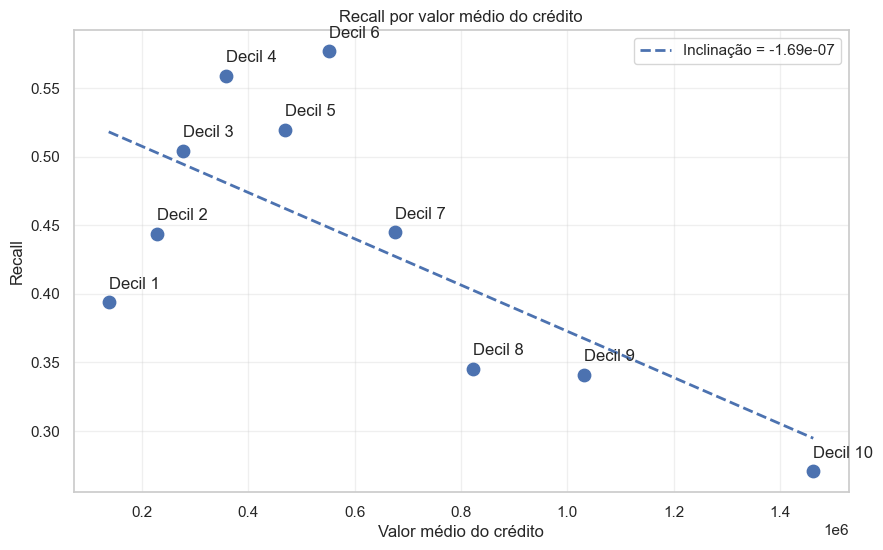

In [51]:
import numpy as np
import matplotlib.pyplot as plt

x = resultado["Valor Médio"]
y = resultado["Recall"]

coef = np.polyfit(x, y, 1)
reta = np.poly1d(coef)

plt.figure(figsize=(10,6))

plt.scatter(x, y, s=80)

plt.plot(
    x,
    reta(x),
    linestyle="--",
    linewidth=2,
    label=f"Inclinação = {coef[0]:.2e}"
)

for _, row in resultado.iterrows():
    plt.text(
        row["Valor Médio"],
        row["Recall"] + 0.01,
        row["Faixa"]
    )

plt.xlabel("Valor médio do crédito")
plt.ylabel("Recall")

plt.title("Recall por valor médio do crédito")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

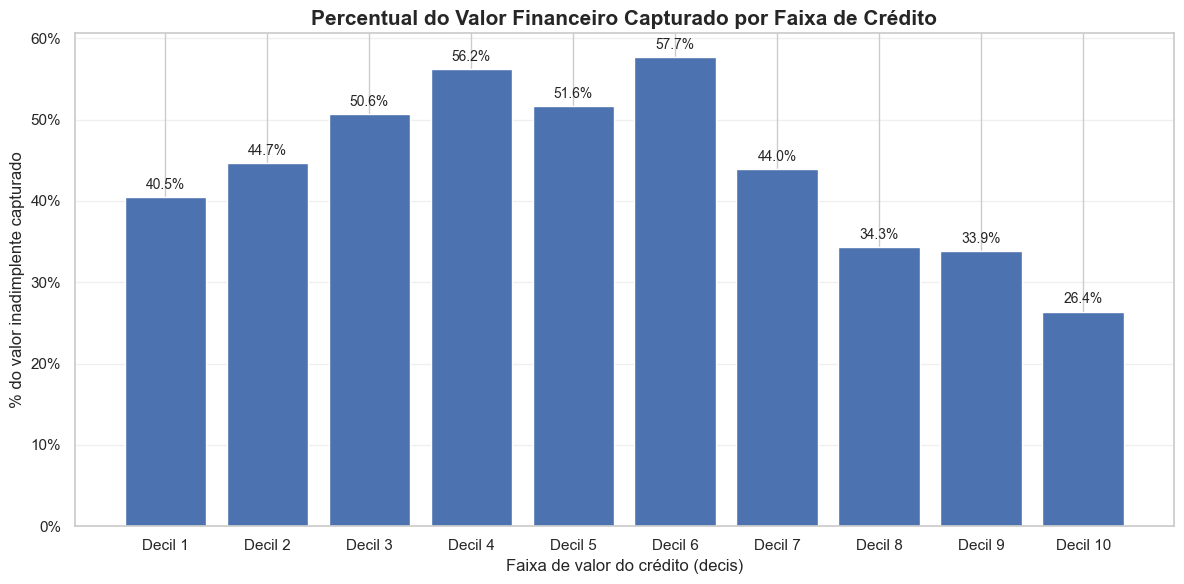

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

resultado = resultado.sort_values("Valor Médio")

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    resultado["Faixa"].astype(str),
    resultado["% Valor Capturado"] * 100
)

# Valores nas barras
for bar in bars:
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 1,
        f"{altura:.1f}%",
        ha="center",
        fontsize=10
    )

ax.set_title(
    "Percentual do Valor Financeiro Capturado por Faixa de Crédito",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Faixa de valor do crédito (decis)")
ax.set_ylabel("% do valor inadimplente capturado")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
import os
import pandas as pd
import mlflow
import mlflow.sklearn
import shap
import matplotlib.pyplot as plt

from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
)


# ======================================================
# MLflow
# ======================================================

mlflow.set_tracking_uri(
    os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000")
)

mlflow.set_experiment("final-model")

mlflow.sklearn.autolog(disable=True)


# ======================================================
# Modelo
# ======================================================

modelo_final = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=950,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


# ======================================================
# Pipeline
# ======================================================

pipeline = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", modelo_final)
])


# ======================================================
# Treino + MLflow
# ======================================================

with mlflow.start_run(run_name="champion-model") as run:

    run_id = run.info.run_id

    print("=" * 50)
    print("RUN:", run_id)
    print("ARTIFACT URI:", mlflow.get_artifact_uri())
    print("=" * 50)


    mlflow.set_tags({
        "model_role": "champion",
        "model_stage": "production",
        "algorithm": "LightGBM"
    })


    # ==================================================
    # Treinamento
    # ==================================================

    pipeline.fit(X_train, y_train)

    print("Treinamento finalizado")


    # ==================================================
    # Predição
    # ==================================================

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= best_threshold).astype(int)


    # ==================================================
    # Métricas
    # ==================================================

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)


    metricas = calcular_metricas(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob
    )


    mlflow.log_metrics({
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "ks": metricas["KS"]
    })

    mlflow.log_param(
        "decision_threshold",
        float(best_threshold)
    )


    # ==================================================
    # Classification report
    # ==================================================

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    mlflow.log_dict(
        report,
        "classification_report.json"
    )


    # ==================================================
    # Matriz confusão
    # ==================================================

    fig, ax = plt.subplots(figsize=(6, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        colorbar=False,
        ax=ax
    )

    ax.set_title("Matriz de Confusão")

    mlflow.log_figure(
        fig,
        "confusion_matrix.png"
    )

    plt.close(fig)


    # ==================================================
    # Feature Importance
    # ==================================================

    modelo = pipeline.named_steps["modelo"]

    feature_importance = pd.DataFrame({
        "feature": modelo.feature_name_,
        "importance": modelo.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )


    mlflow.log_dict(
        feature_importance.to_dict(),
        "feature_importance.json"
    )


    fig = plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance.head(20)["feature"],
        feature_importance.head(20)["importance"]
    )

    plt.gca().invert_yaxis()
    plt.title("Feature Importance")

    mlflow.log_figure(
        fig,
        "feature_importance.png"
    )

    plt.close(fig)


    # ==================================================
    # SHAP
    # ==================================================

    X_test_transformado = (
        pipeline
        .named_steps["preprocessador"]
        .transform(X_test)
    )


    feature_names = (
        pipeline
        .named_steps["preprocessador"]
        .get_feature_names_out()
    )


    explainer = shap.TreeExplainer(modelo)

    shap_values = explainer.shap_values(
        X_test_transformado,
        check_additivity=False
    )


    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values


    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values_plot,
        X_test_transformado,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()

    mlflow.log_figure(
        plt.gcf(),
        "shap_summary.png"
    )

    plt.close()


    plt.figure(figsize=(10, 6))

    shap.summary_plot(
        shap_values_plot,
        X_test_transformado,
        feature_names=feature_names,
        plot_type="bar",
        max_display=20,
        show=False
    )

    plt.tight_layout()

    mlflow.log_figure(
        plt.gcf(),
        "shap_importance.png"
    )

    plt.close()


    # ==================================================
    # DEBUG ARTIFACTS ANTES MODELO
    # ==================================================

    client = MlflowClient()

    print("\nARTIFACTS ANTES MODELO")

    for artifact in client.list_artifacts(run_id):
        print(artifact.path)


    # ==================================================
    # Registro Modelo MLflow 3.3.2
    # ==================================================

    input_example = X_test.head(5)


    output_example = pd.DataFrame(
        pipeline.predict_proba(input_example),
        columns=["prob_0", "prob_1"]
    )


    signature = infer_signature(
        input_example,
        output_example
    )


    print("\nSalvando modelo...")


    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline,
        name="champion",
        signature=signature,
        input_example=input_example
    )


    print(
        "MODEL URI:",
        model_info.model_uri
    )


    # ==================================================
    # Registry
    # ==================================================

    registered_model = mlflow.register_model(
        model_uri=model_info.model_uri,
        name="lgb_prob_default_production"
    )


    client.set_registered_model_alias(
        name="lgb_prob_default_production",
        alias="champion",
        version=registered_model.version
    )


    print(
        f"Modelo registrado: versão {registered_model.version}"
    )


# ======================================================
# Resultado
# ======================================================

print("=" * 50)
print("MÉTRICAS FINAIS")
print("=" * 50)

print(f"Threshold: {best_threshold:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"KS: {metricas['KS']:.4f}")

RUN: e81e26974f17439993329cfbfae1c5ef
ARTIFACT URI: /mlflow/artifacts/4/e81e26974f17439993329cfbfae1c5ef/artifacts


2026/07/26 14:02:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Treinamento finalizado


c:\Users\eduar\anaconda3\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



ARTIFACTS ANTES MODELO
classification_report.json
confusion_matrix.png
feature_importance.json
feature_importance.png
feature_importance_gain.json
feature_importance_gain.png
feature_importance_split.json
feature_importance_split.png
shap_importance.png
shap_summary.png

Salvando modelo...


c:\Users\eduar\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


MODEL URI: models:/m-0ed26fdf111445dabb7b8632fc14f69a


Registered model 'lgb_prob_default_production' already exists. Creating a new version of this model...
2026/07/26 14:03:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lgb_prob_default_production, version 8
Created version '8' of model 'lgb_prob_default_production'.


Modelo registrado: versão 8
🏃 View run champion-model at: http://localhost:5000/#/experiments/4/runs/e81e26974f17439993329cfbfae1c5ef
🧪 View experiment at: http://localhost:5000/#/experiments/4
MÉTRICAS FINAIS
Threshold: 0.6500
Precision: 0.2603
Recall: 0.4544
F1-score: 0.3310
PR-AUC: 0.2753
ROC-AUC: 0.7790
KS: 0.4223
